## Business Problem

HomeIQ receives thousands of customer support messages from different communication channels including email, chat, phone transcripts, mobile applications, and product reviews.

These messages contain valuable information about customer complaints, product problems, and customer feedback. However, manually reviewing and categorizing every message requires significant time and resources.

The goal of this project is to develop a Natural Language Processing (NLP) text classification model that automatically predicts the support category of customer messages.

The model will classify messages into categories such as Voice Assistant, Security Alert, Warranty Return, Installation, Connectivity, and Energy Saving.

This solution can help HomeIQ:
- Automatically route customer requests to the correct support team
- Reduce customer response time
- Identify common product problems
- Improve customer satisfaction
- Analyze trends in customer feedback

In [4]:
import pandas as pd

# Load the dataset
df = pd.read_excel("NLP_Dataset_16_Smart_Home_Device_Support.xlsx")

# Display the first 5 rows
df.head()

,SupportID,SupportDate,Channel,City,DeviceType,CustomerSegment,SupportMessage,SupportCategory,IssueSeverity
0,SMT-001,2026-04-10,Email,Oshawa,Door Sensor,Returning User,"Voice commands worked yesterday, but today the...",Voice_Assistant,Medium
1,SMT-002,2026-04-15,Chat,Ottawa,Smart Speaker,Renter,The app did not notify me when the back door o...,Security_Alert,High
2,SMT-003,2026-04-20,Phone Transcript,Mississauga,Hub,Homeowner,My smart light stopped working after two weeks...,Warranty_Return,High
3,SMT-004,2026-04-25,Product Review,Oshawa,Hub,Renter,"Voice commands worked yesterday, but today the...",Voice_Assistant,Medium
4,SMT-005,2026-04-30,Mobile App,Brampton,Smart Light,Small Business,The light works near the router but fails in t...,Connectivity,High


In [6]:
print("Shape:", df.shape)

print("\nColumns:", list(df.columns))

Shape: (120, 9)

Columns: ['SupportID', 'SupportDate', 'Channel', 'City', 'DeviceType', 'CustomerSegment', 'SupportMessage', 'SupportCategory', 'IssueSeverity']


In [8]:
df.isnull().sum()

SupportID          0
SupportDate        0
Channel            0
City               0
DeviceType         0
CustomerSegment    0
SupportMessage     0
SupportCategory    0
IssueSeverity      0
dtype: int64

In [10]:
df["SupportCategory"].value_counts()

SupportCategory
Voice_Assistant    20
Security_Alert     20
Warranty_Return    20
Connectivity       20
Energy_Saving      20
Installation       20
Name: count, dtype: int64

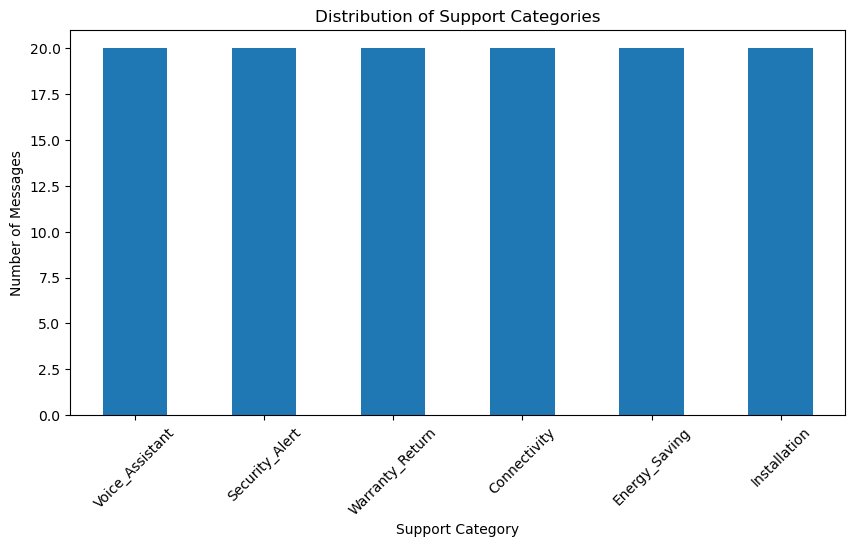

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df["SupportCategory"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Support Categories")
plt.xlabel("Support Category")
plt.ylabel("Number of Messages")

plt.xticks(rotation=45)

plt.show()

# Task 2: Text Preprocessing

In [21]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()


def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(
        r"[^a-z\s]",
        "",
        text
    )

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [23]:
df["Clean_Message"] = df["SupportMessage"].apply(
    preprocess_text
)

In [25]:
df.head()

,SupportID,SupportDate,Channel,City,DeviceType,CustomerSegment,SupportMessage,SupportCategory,IssueSeverity,Clean_Message
0,SMT-001,2026-04-10,Email,Oshawa,Door Sensor,Returning User,"Voice commands worked yesterday, but today the...",Voice_Assistant,Medium,voice command worked yesterday today speaker s...
1,SMT-002,2026-04-15,Chat,Ottawa,Smart Speaker,Renter,The app did not notify me when the back door o...,Security_Alert,High,app notify back door opened
2,SMT-003,2026-04-20,Phone Transcript,Mississauga,Hub,Homeowner,My smart light stopped working after two weeks...,Warranty_Return,High,smart light stopped working two week need warr...
3,SMT-004,2026-04-25,Product Review,Oshawa,Hub,Renter,"Voice commands worked yesterday, but today the...",Voice_Assistant,Medium,voice command worked yesterday today speaker s...
4,SMT-005,2026-04-30,Mobile App,Brampton,Smart Light,Small Business,The light works near the router but fails in t...,Connectivity,High,light work near router fails bedroom brampton ...


Preprocessing removes unnecessary information such as punctuation, capitalization differences, and common English words. This allows the machine learning model to focus on important terms related to customer issues.

# Task 3: Exploratory Text Analysis 

In [28]:
from collections import Counter


all_words = " ".join(
    df["Clean_Message"]
).split()


word_counts = Counter(all_words)


word_counts.most_common(20)

[('homeiq', 48),
 ('camera', 25),
 ('thermostat', 20),
 ('say', 15),
 ('app', 15),
 ('light', 15),
 ('work', 15),
 ('hub', 15),
 ('cannot', 15),
 ('security', 15),
 ('alert', 15),
 ('speaker', 10),
 ('device', 10),
 ('door', 10),
 ('smart', 10),
 ('stopped', 10),
 ('week', 10),
 ('warranty', 10),
 ('replacement', 10),
 ('fails', 10)]

In [30]:
common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=[
        "Word",
        "Frequency"
    ]
)

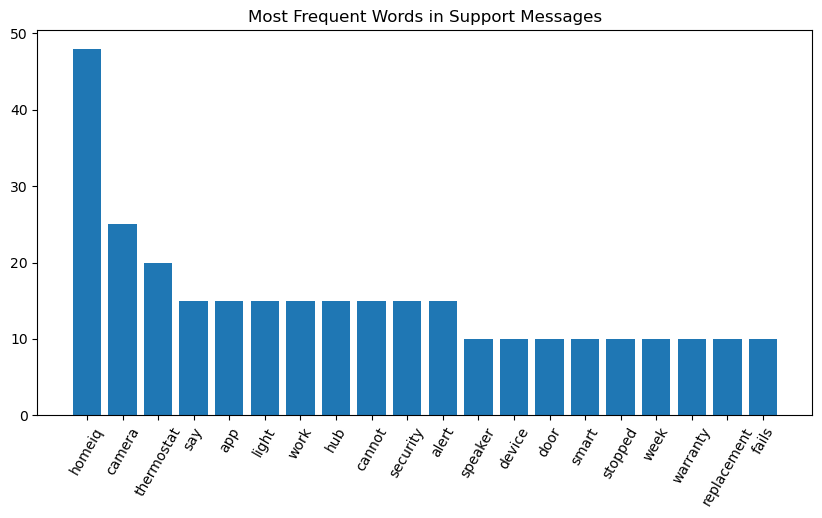

In [32]:
plt.figure(figsize=(10,5))

plt.bar(
    common_words["Word"],
    common_words["Frequency"]
)

plt.xticks(rotation=60)

plt.title(
    "Most Frequent Words in Support Messages"
)

plt.show()

The frequent words represent the main themes appearing in customer requests. Words related to devices, connection problems, warranty, installation, and security indicate the most common customer concerns.

# Task 4: POS Tagging and NER 

In [59]:
import nltk

from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.tree import Tree

# Download required resources (run once)
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("maxent_ne_chunker_tab")
nltk.download("words")


# Select three sample customer messages from different categories
samples = [
    (
        df[df["SupportMessage"].str.contains("HomeIQ", case=False, na=False)]["SupportMessage"].iloc[0],
        "Organization Example"
    ),
    (
        df[df["SupportMessage"].str.contains("Brampton|Oshawa|Calgary|Toronto", case=False, na=False, regex=True)]["SupportMessage"].iloc[0],
        "Location Example"
    ),
    (
        df[df["SupportMessage"].str.contains("June|2026", case=False, na=False)]["SupportMessage"].iloc[0],
        "Date Example"
    )
]

for i, (text, category) in enumerate(samples, 1):

    print(f"--- Sample {i} [{category}] ---")
    
    print("Text:")
    print(text)

    # Tokenization
    tokens = word_tokenize(text)

    # POS tagging
    tagged = pos_tag(tokens)

    print("\nPOS Tags:")
    for token, tag in tagged:
        print(f"{token:<20} {tag}")

    # Named Entity Recognition
    tree = ne_chunk(tagged)

    entities = []

    for subtree in tree:
        if isinstance(subtree, Tree):
            entity_name = " ".join(
                word for word, tag in subtree.leaves()
            )
            
            entities.append(
                (entity_name, subtree.label())
            )

    print("\nNamed Entities:")
    print(entities if entities else "(none detected)")

    print("\n" + "-"*50 + "\n")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nafij\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\nafij\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\nafij\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\nafij\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


--- Sample 1 [Organization Example] ---
Text:
The light works near the router but fails in the bedroom in Brampton. #HomeIQ

POS Tags:
The                  DT
light                JJ
works                NNS
near                 IN
the                  DT
router               NN
but                  CC
fails                VBZ
in                   IN
the                  DT
bedroom              NN
in                   IN
Brampton             NNP
.                    .
#                    #
HomeIQ               NNP

Named Entities:
[('Brampton', 'GPE'), ('HomeIQ', 'ORGANIZATION')]

--------------------------------------------------

--- Sample 2 [Location Example] ---
Text:
The light works near the router but fails in the bedroom in Brampton. #HomeIQ

POS Tags:
The                  DT
light                JJ
works                NNS
near                 IN
the                  DT
router               NN
but                  CC
fails                VBZ
in                   IN
the       

## POS Tagging and Named Entity Recognition Interpretation

Three customer support messages were analyzed using POS tagging and Named Entity Recognition.

POS tagging identified different word categories in customer messages:

- Nouns:
  - light
  - router
  - bedroom
  - device
  - camera

  These words represent products or objects related to customer issues.

- Verbs:
  - works
  - fails
  - stopped

  These describe actions or problems experienced by customers.

- Adjectives:
  - smart
  - unavailable
  - security

  These provide additional information about product conditions and issue types.

Named Entity Recognition identified important entities from the messages:

- Brampton → GPE (location)
- HomeIQ → Organization

These entities are useful for business analysis because they allow companies to identify where problems occur and connect feedback to specific products or services.

However, some technical terms such as "camera" or "security" were incorrectly classified by NLTK as organizations. This shows that general-purpose NER models may have limitations when analyzing domain-specific customer support text. A specialized business NER model could provide more accurate results.

# Task 5: Feature Extraction 

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(
    max_features=5000
)


X = tfidf.fit_transform(
    df["Clean_Message"]
)


y = df["SupportCategory"]
print("TF-IDF matrix shape:", X.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))
print("First 15 features:", tfidf.get_feature_names_out()[:15])

TF-IDF matrix shape: (120, 121)
Number of features: 121
First 15 features: ['alert' 'alexa' 'almost' 'anymore' 'app' 'approved' 'arrived' 'assistant'
 'back' 'bedroom' 'bluetooth' 'brampton' 'broken' 'calgary' 'camera']


Machine learning algorithms require numerical input. TF-IDF converts text into numbers by measuring how important each word is within customer messages.

# Task 6: Classification Model 

In [73]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [75]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(
    max_iter=1000
)


model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [79]:
y_pred = model.predict(
    X_test
)

print("First 5 predictions:", list(y_pred[:5]))
print("First 5 actual     :", list(y_test[:5]))

First 5 predictions: ['Security_Alert', 'Voice_Assistant', 'Security_Alert', 'Warranty_Return', 'Installation']
First 5 actual     : ['Security_Alert', 'Voice_Assistant', 'Security_Alert', 'Warranty_Return', 'Installation']


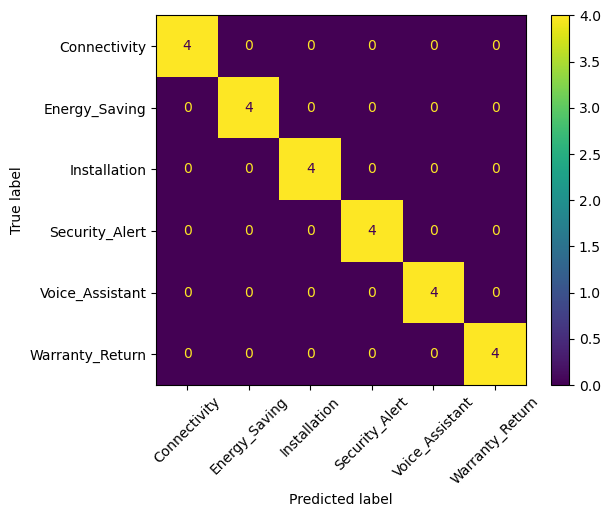

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.show()

The accuracy shows how often the model correctly identifies the customer's support category.

A higher score means the system can automatically classify more customer requests correctly.

Errors are important because incorrect classifications may send customers to the wrong support team, increasing resolution time.

Categories with unique keywords are usually easier to predict, while categories with similar language may be confused.

# Task 8: Final Business Summary 

The project developed an NLP classification model for HomeIQ customer support messages.

The SupportMessage column was used as the text input, and SupportCategory was used as the target variable.

The text data was cleaned using lowercase conversion, punctuation removal, stopword removal, tokenization, and lemmatization.

TF-IDF was used to transform text into numerical features, and Logistic Regression was used for classification.

The model can help HomeIQ automatically categorize customer requests and improve support efficiency.

A key insight from the dataset is that customers frequently report issues related to device connectivity, installation, warranty, and voice assistant features.

A limitation is that classification performance depends on the quality and balance of the available support messages. Some categories may have fewer examples, making them harder to predict.